# Test 3 — A/B-тест: заміна «серця» на «галочку»

**Питання:** впроваджувати нововведення для всіх чи відхилити?

**Дизайн:** непарний `sender_id` - тест, парний - контроль; старт 24.03 о 16:00.


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
rng = np.random.default_rng(42)

# 1. Дані та перевірка якості

In [15]:
df = pd.read_csv("../data/test_3/Test_3.csv", sep=';')
df['time_stamp'] = pd.to_datetime(df['time_stamp'], format='%d.%m.%Y %H:%M')
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%d.%m.%Y')

print(f"Рядків (кожен рядок = один лайк): {len(df):,}")
print(f"Унікальних відправників: {df['sender_id'].nunique():,}")
print(f"Період: {df['time_stamp'].min()} — {df['time_stamp'].max()}")
print(f"Точних дублікатів рядків: {df.duplicated().sum():,} (час до хвилини → кілька лайків за хвилину можливі, тому не видаляємо)")
print("Платформи:", df['platform_id'].value_counts().to_dict(), "(6 — десктоп, 7 — мобільна)")
print("Стать:", df['gender'].value_counts().to_dict())
print("Лайків до реєстрації (аномалія даних):", (df['time_stamp'].dt.normalize() < df['reg_date']).sum())

Рядків (кожен рядок = один лайк): 768,439
Унікальних відправників: 26,321
Період: 2017-03-13 00:00:00 — 2017-03-27 00:00:00
Точних дублікатів рядків: 518,178 (час до хвилини → кілька лайків за хвилину можливі, тому не видаляємо)
Платформи: {6: 446092, 7: 322347} (6 — десктоп, 7 — мобільна)
Стать: {'m': 659569, 'f': 108699, ' ': 171}
Лайків до реєстрації (аномалія даних): 29


# 2. Параметри експерименту

Тривалість тесту береться з даних (до останньої мітки часу). **Pre-період** — вікно такої ж тривалості безпосередньо перед стартом; з нього беремо *когорту* й коваріату для CUPED.

In [16]:
TEST_START = pd.Timestamp('2017-03-24 16:00:00')
TEST_END = df['time_stamp'].max()
DURATION = TEST_END - TEST_START
PRE_START = TEST_START - DURATION

print(f"Тест: {TEST_START} → {TEST_END}  (тривалість {DURATION})")
print(f"Pre-вікно: {PRE_START} → {TEST_START}")
if DURATION < pd.Timedelta(days=7):
    print("УВАГА: тест коротший за тиждень — тижнева сезонність не покрита, ефект може бути зміщений днем тижня.")

df['group'] = np.where(df['sender_id'] % 2 == 1, 'test', 'control')   # непарний → test
pre = df[(df['time_stamp'] >= PRE_START) & (df['time_stamp'] < TEST_START)]
exp = df[df['time_stamp'] >= TEST_START]
print(f"Лайків у pre: {len(pre):,};  в експерименті: {len(exp):,}")

Тест: 2017-03-24 16:00:00 → 2017-03-27 00:00:00  (тривалість 2 days 08:00:00)
Pre-вікно: 2017-03-22 08:00:00 → 2017-03-24 16:00:00
УВАГА: тест коротший за тиждень — тижнева сезонність не покрита, ефект може бути зміщений днем тижня.
Лайків у pre: 115,103;  в експерименті: 107,592


# 3. Когорта та метрики на користувача

**Когорта** = користувачі, які поставили ≥1 лайк у pre-вікні (вони існували до тесту, і на них нововведення не могло вплинути при формуванні вибірки).
Для них рахуємо лайки в експерименті, **включно з нулями** — це і є коректна «кількість лайків на користувача».

In [17]:
users = pd.DataFrame({'sender_id': pre['sender_id'].unique()})
users['group'] = np.where(users['sender_id'] % 2 == 1, 'test', 'control')
users['pre_likes'] = users['sender_id'].map(pre.groupby('sender_id').size()).fillna(0)
users['likes'] = users['sender_id'].map(exp.groupby('sender_id').size()).fillna(0)
users['active'] = (users['likes'] > 0).astype(int)

attrs = pre.groupby('sender_id').agg(
    gender=('gender', 'first'),
    platform_id=('platform_id', lambda s: s.value_counts().idxmax()),
    reg_date=('reg_date', 'first'),
)
users = users.merge(attrs, left_on='sender_id', right_index=True, how='left')
users['is_new'] = users['reg_date'] >= (TEST_START - pd.Timedelta(days=30))   # зареєстровані за 30 днів до тесту

print("Розмір когорти за групами:")
display(users['group'].value_counts().to_frame('users'))
display(users.groupby('group')[['pre_likes', 'likes', 'active']].mean())

Розмір когорти за групами:


,users
group,
control,3582
test,3479


,pre_likes,likes,active
group,,,
control,16.354,8.547,0.379
test,16.247,7.897,0.393


## 3.1 Перевірка сплітування (SRM та баланс)

Якщо розбиття по парності `sender_id` зламане, результатам довіряти не можна. Перевіряємо співвідношення груп (SRM, очікуємо 50/50) і баланс за статтю та платформою.

In [18]:
n_t, n_c = (users['group'] == 'test').sum(), (users['group'] == 'control').sum()
chi = stats.chisquare([n_t, n_c])
print(f"SRM (когорта): test={n_t}, control={n_c}, p={chi.pvalue:.3f}  -", "ОК" if chi.pvalue > 0.01 else "ПРОБЛЕМА: розподіл не 50/50")

for col in ['gender', 'platform_id']:
    ct = pd.crosstab(users[col], users['group'])
    p = stats.chi2_contingency(ct)[1]
    print(f"\nБаланс за {col} (chi², p={p:.3f}):")
    display((ct / ct.sum() * 100).round(1))

SRM (когорта): test=3479, control=3582, p=0.220  - ОК

Баланс за gender (chi², p=0.334):


group,control,test
gender,,
,0.000,0.100
f,21.500,21.800
m,78.500,78.100



Баланс за platform_id (chi², p=0.136):


group,control,test
platform_id,,
6,47.200,49.000
7,52.800,51.000


## 3.2 A/A: чи були групи однаковими ДО тесту

Порівнюємо лайки в pre-вікні. Перевіряємо середнє з довірчим інтервалом, а не лише p-value: «немає значущої різниці» ≠ «групи еквівалентні».

In [19]:
def compare(test, ctrl, n_boot=3000):
    """Різниця середніх test − control: bootstrap 95% CI (абсолютний і відносний), Welch t-test, Манн-Вітні."""
    test, ctrl = np.asarray(test, float), np.asarray(ctrl, float)
    m_t, m_c = test.mean(), ctrl.mean()
    diffs, rels = np.empty(n_boot), np.empty(n_boot)
    for i in range(n_boot):
        bt = rng.choice(test, len(test)).mean()
        bc = rng.choice(ctrl, len(ctrl)).mean()
        diffs[i] = bt - bc
        rels[i] = bt / bc - 1 if bc != 0 else np.nan
    return {
        'mean_test': m_t, 'mean_control': m_c,
        'diff': m_t - m_c, 'diff_ci_low': np.percentile(diffs, 2.5), 'diff_ci_high': np.percentile(diffs, 97.5),
        'rel_%': (m_t / m_c - 1) * 100 if m_c != 0 else np.nan,
        'rel_ci_low_%': np.nanpercentile(rels, 2.5) * 100, 'rel_ci_high_%': np.nanpercentile(rels, 97.5) * 100,
        'p_welch': stats.ttest_ind(test, ctrl, equal_var=False).pvalue,
        'p_mwu': stats.mannwhitneyu(test, ctrl, alternative='two-sided').pvalue,
        'n_test': len(test), 'n_control': len(ctrl),
    }

T, Cn = users[users['group'] == 'test'], users[users['group'] == 'control']
aa = compare(T['pre_likes'], Cn['pre_likes'])
print(f"A/A (лайки в pre на користувача): test={aa['mean_test']:.2f}, control={aa['mean_control']:.2f}, "
      f"різниця {aa['rel_%']:+.1f}% [95% CI {aa['rel_ci_low_%']:+.1f}%; {aa['rel_ci_high_%']:+.1f}%], p_welch={aa['p_welch']:.3f}, p_mwu={aa['p_mwu']:.3f}")

A/A (лайки в pre на користувача): test=16.25, control=16.35, різниця -0.7% [95% CI -12.5%; +12.4%], p_welch=0.919, p_mwu=0.606


# 4. Основний результат: A/B

In [20]:
def winsorize(t, c, q=0.99):
    cap = np.quantile(np.concatenate([t, c]), q)
    return np.minimum(t, cap), np.minimum(c, cap), cap

# --- CUPED: y_adj = y − θ·(x − mean(x)), x = лайки в pre
x_all = users['pre_likes'].values.astype(float); y_all = users['likes'].values.astype(float)
theta = np.cov(y_all, x_all)[0, 1] / np.var(x_all, ddof=1)
users['likes_cuped'] = users['likes'] - theta * (users['pre_likes'] - users['pre_likes'].mean())
print(f"CUPED: кореляція pre↔test = {np.corrcoef(x_all, y_all)[0,1]:.2f}, θ = {theta:.2f}")

t_w, c_w, cap = winsorize(T['likes'].values, Cn['likes'].values)
print(f"Winsorize на 99-му перцентилі = {cap:.0f} лайків")

results = pd.DataFrame({
    '1. Лайки на користувача (основна)': compare(T['likes'], Cn['likes']),
    '2. Winsorize 99%':                  compare(t_w, c_w),
    '3. CUPED':                          compare(users.loc[users['group']=='test', 'likes_cuped'],
                                                 users.loc[users['group']=='control', 'likes_cuped']),
    '4. log(1+лайки)':                   compare(np.log1p(T['likes']), np.log1p(Cn['likes'])),
    '5. Лайки | активні (умовно)':       compare(T.loc[T['likes'] > 0, 'likes'], Cn.loc[Cn['likes'] > 0, 'likes']),
}).T
display(results[['mean_test', 'mean_control', 'diff', 'rel_%', 'rel_ci_low_%', 'rel_ci_high_%', 'p_welch', 'p_mwu', 'n_test', 'n_control']])

CUPED: кореляція pre↔test = 0.70, θ = 0.53
Winsorize на 99-му перцентилі = 110 лайків


,mean_test,mean_control,diff,rel_%,rel_ci_low_%,rel_ci_high_%,p_welch,p_mwu,n_test,n_control
1. Лайки на користувача (основна),7.897,8.547,-0.649,-7.596,-23.162,10.941,0.409,0.322,"3,479.000","3,582.000"
2. Winsorize 99%,7.151,6.969,0.182,2.606,-8.751,15.306,0.672,0.322,"3,479.000","3,582.000"
3. CUPED,7.926,8.519,-0.593,-6.961,-18.317,5.830,0.290,0.737,"3,479.000","3,582.000"
4. log(1+лайки),0.885,0.862,0.022,2.599,-4.216,9.831,0.482,0.322,"3,479.000","3,582.000"
5. Лайки | активні (умовно),20.113,22.527,-2.413,-10.713,-25.123,5.802,0.216,0.689,"1,366.000","1,359.000"


Метрика 5 («лайки серед активних») — це **умовна** метрика: вона дивиться лише на тих, хто вже щось лайкнув, тобто відбирає вибірку за результатом. Саме так рахувала перша версія. Її треба читати тільки разом із часткою активних (нижче).

In [21]:
# --- Частка активних (хоча б 1 лайк за тест)
a_t, a_c = T['active'], Cn['active']
p_t, p_c = a_t.mean(), a_c.mean()
pool = (a_t.sum() + a_c.sum()) / (len(a_t) + len(a_c))
z = (p_t - p_c) / np.sqrt(pool * (1 - pool) * (1/len(a_t) + 1/len(a_c)))
p_val = 2 * (1 - stats.norm.cdf(abs(z)))
se = np.sqrt(p_t*(1-p_t)/len(a_t) + p_c*(1-p_c)/len(a_c))
print(f"Частка активних у тесті: test={p_t*100:.1f}%, control={p_c*100:.1f}%, "
      f"різниця {(p_t-p_c)*100:+.2f} п.п. [95% CI {((p_t-p_c)-1.96*se)*100:+.2f}; {((p_t-p_c)+1.96*se)*100:+.2f}], p={p_val:.3f}")

# --- Скільки може виявити цей тест (MDE)
main = results.iloc[0]
sd_t, sd_c = T['likes'].std(), Cn['likes'].std()
se_diff = np.sqrt(sd_t**2/len(T) + sd_c**2/len(Cn))
mde_abs = (stats.norm.ppf(0.975) + stats.norm.ppf(0.8)) * se_diff
print(f"MDE (α=5%, потужність 80%): ±{mde_abs:.2f} лайків на користувача = ±{mde_abs/main['mean_control']*100:.1f}% від контролю")

Частка активних у тесті: test=39.3%, control=37.9%, різниця +1.32 п.п. [95% CI -0.95; +3.60], p=0.253
MDE (α=5%, потужність 80%): ±2.20 лайків на користувача = ±25.8% від контролю


## 4.1 Візуалізації результату

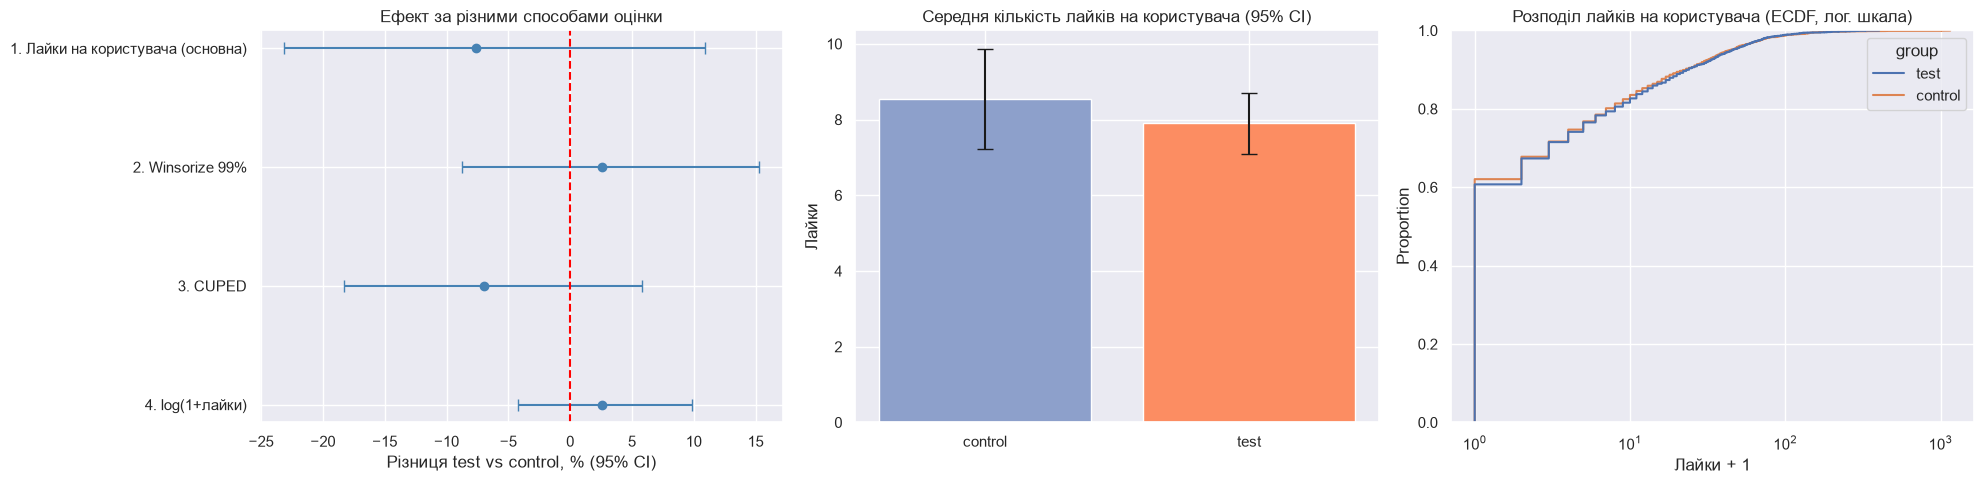

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Відносна різниця з CI за різними метриками
r = results.iloc[:4]
ypos = np.arange(len(r))[::-1]
axes[0].errorbar(r['rel_%'], ypos, xerr=[r['rel_%'] - r['rel_ci_low_%'], r['rel_ci_high_%'] - r['rel_%']], fmt='o', capsize=4, color='steelblue')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_yticks(ypos); axes[0].set_yticklabels(r.index)
axes[0].set_xlabel('Різниця test vs control, % (95% CI)'); axes[0].set_title('Ефект за різними способами оцінки')

# 2) Середнє з CI по групах
means = pd.DataFrame({'group': ['control', 'test'],
                      'mean': [Cn['likes'].mean(), T['likes'].mean()],
                      'se': [Cn['likes'].std()/np.sqrt(len(Cn)), T['likes'].std()/np.sqrt(len(T))]})
axes[1].bar(means['group'], means['mean'], yerr=1.96*means['se'], capsize=6, color=['#8da0cb', '#fc8d62'])
axes[1].set_title('Середня кількість лайків на користувача (95% CI)'); axes[1].set_ylabel('Лайки')

# 3) Розподіл (ECDF, лог-шкала по лайках+1)
users['likes_p1'] = users['likes'] + 1
sns.ecdfplot(data=users, x='likes_p1', hue='group', log_scale=True, ax=axes[2])
axes[2].set_title('Розподіл лайків на користувача (ECDF, лог. шкала)'); axes[2].set_xlabel('Лайки + 1')
plt.tight_layout(); plt.show()

# 5. Динаміка по днях і ефект новизни

Якщо ефект з'являється лише в перші дні й зникає — це ефект новизни. Також лінії груп до старту мають збігатися (візуальний A/A).
Доба старту (24.03) розділена о 16:00, тому містить і pre-, і post-години.

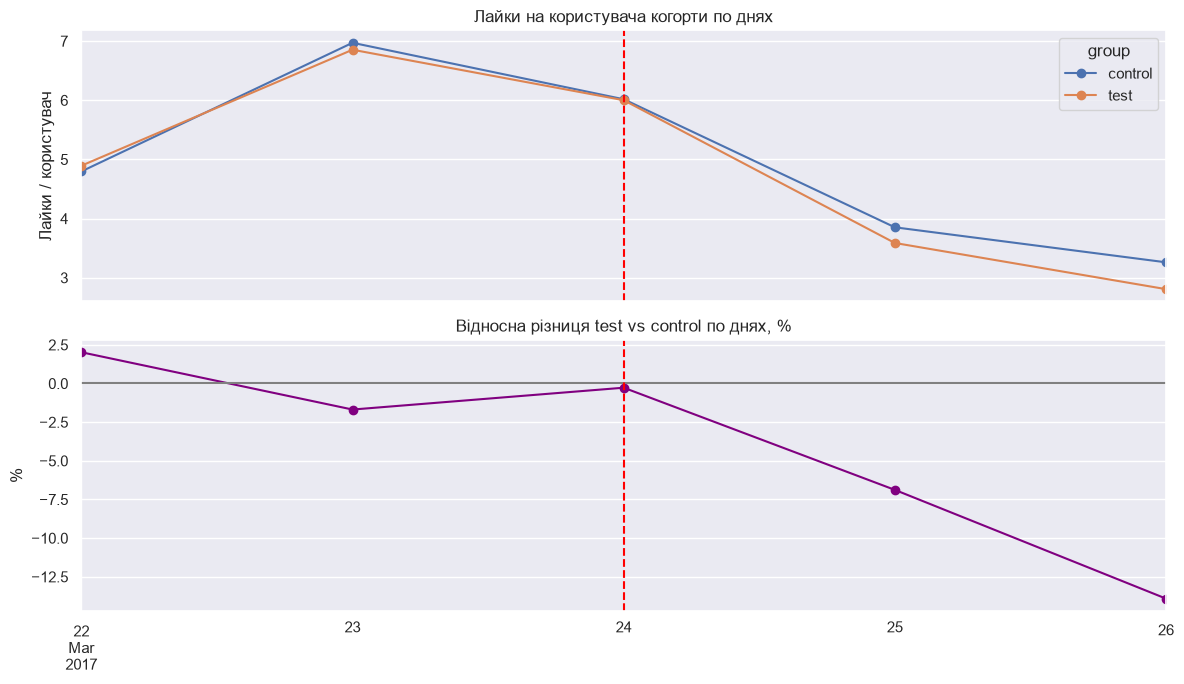

перша половина: -4.9% [95% CI -22.5; +14.5], p_welch=0.623
друга половина: -11.0% [95% CI -27.5; +10.5], p_welch=0.299


In [23]:
cohort_ids = set(users['sender_id'])
d = df[df['sender_id'].isin(cohort_ids) & (df['time_stamp'] >= PRE_START)].copy()
d['date'] = d['time_stamp'].dt.normalize()
daily = d.groupby(['date', 'group']).size().unstack(fill_value=0)
sizes = users['group'].value_counts()
daily_pu = daily.div(sizes[daily.columns], axis=1)
rel = (daily_pu['test'] / daily_pu['control'] - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
daily_pu.plot(ax=axes[0], marker='o'); axes[0].set_title('Лайки на користувача когорти по днях'); axes[0].set_ylabel('Лайки / користувач')
axes[1].plot(rel.index, rel.values, marker='o', color='purple'); axes[1].axhline(0, color='gray')
axes[1].set_title('Відносна різниця test vs control по днях, %'); axes[1].set_ylabel('%')
for ax in axes:
    ax.axvline(TEST_START.normalize(), color='red', ls='--')
plt.tight_layout(); plt.show()

# Перша vs друга половина тесту
mid = TEST_START + DURATION / 2
for name, part in [('перша половина', exp[exp['time_stamp'] < mid]), ('друга половина', exp[exp['time_stamp'] >= mid])]:
    per_user = users['sender_id'].map(part.groupby('sender_id').size()).fillna(0)
    r_ = compare(per_user[users['group'] == 'test'], per_user[users['group'] == 'control'], n_boot=1500)
    print(f"{name}: {r_['rel_%']:+.1f}% [95% CI {r_['rel_ci_low_%']:+.1f}; {r_['rel_ci_high_%']:+.1f}], p_welch={r_['p_welch']:.3f}")

# 6. Сегменти

Дивимось, чи ефект не ховається в підгрупі (платформа, стать, нові користувачі). Сегментів кілька — це **множинні порівняння**, тому значущість у сегменті слід оцінювати з поправкою (Bonferroni: α/кількість сегментів) і трактувати як гіпотезу для наступного тесту, а не як висновок.

,сегмент,n_test,n_control,mean_test,mean_control,rel_%,ci_low_%,ci_high_%,p_welch,значущо_після_Bonferroni
0,платформа = 6,1704,1690,8.990,9.020,-0.327,-18.126,19.637,0.974,False
1,платформа = 7,1775,1892,6.848,8.124,-15.703,-37.989,16.137,0.308,False
2,стать = f,759,769,3.879,3.501,10.802,-24.375,62.621,0.603,False
3,стать = m,2718,2813,9.017,9.926,-9.159,-25.663,12.240,0.354,False
4,реєстрація <30 днів до тесту = False,1299,1361,10.116,12.404,-18.444,-39.912,10.669,0.206,False
5,реєстрація <30 днів до тесту = True,2180,2221,6.575,6.183,6.347,-12.085,29.163,0.522,False


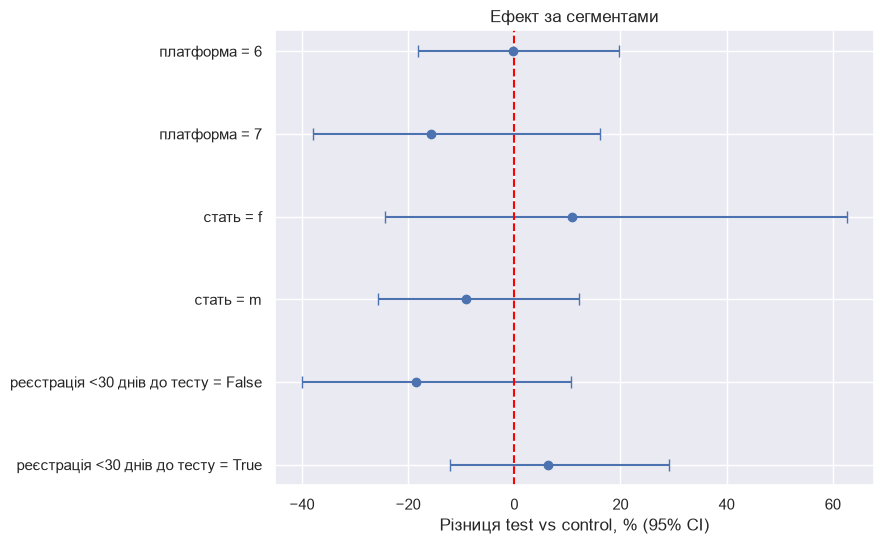

In [24]:
rows = []
for col, label in [('platform_id', 'платформа'), ('gender', 'стать'), ('is_new', 'реєстрація <30 днів до тесту')]:
    for val, g in users.groupby(col):
        gt, gc = g[g['group'] == 'test'], g[g['group'] == 'control']
        if len(gt) >= 100 and len(gc) >= 100:
            r_ = compare(gt['likes'], gc['likes'], n_boot=1500)
            rows.append({'сегмент': f'{label} = {val}', 'n_test': len(gt), 'n_control': len(gc),
                         'mean_test': r_['mean_test'], 'mean_control': r_['mean_control'],
                         'rel_%': r_['rel_%'], 'ci_low_%': r_['rel_ci_low_%'], 'ci_high_%': r_['rel_ci_high_%'], 'p_welch': r_['p_welch']})
seg = pd.DataFrame(rows)
alpha_bonf = 0.05 / max(len(seg), 1)
seg['значущо_після_Bonferroni'] = seg['p_welch'] < alpha_bonf
display(seg)

if len(seg):
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(seg) + 2))
    y = np.arange(len(seg))[::-1]
    ax.errorbar(seg['rel_%'], y, xerr=[seg['rel_%'] - seg['ci_low_%'], seg['ci_high_%'] - seg['rel_%']], fmt='o', capsize=4)
    ax.axvline(0, color='red', ls='--'); ax.set_yticks(y); ax.set_yticklabels(seg['сегмент'])
    ax.set_xlabel('Різниця test vs control, % (95% CI)'); ax.set_title('Ефект за сегментами')
    plt.tight_layout(); plt.show()

# 7. Оригінальний підхід (для порівняння)

In [25]:
# Як у першій версії: лише користувачі, що мали ≥1 лайк ПІД ЧАС тесту, порівняння Манна-Вітні
likes_ab = exp.groupby(['sender_id', 'group']).size().reset_index(name='likes_count')
t0 = likes_ab.loc[likes_ab['group'] == 'test', 'likes_count']; c0 = likes_ab.loc[likes_ab['group'] == 'control', 'likes_count']
print(f"Активні в тесті: test n={len(t0)}, control n={len(c0)}; середнє test={t0.mean():.2f}, control={c0.mean():.2f}, "
      f"p_mwu={stats.mannwhitneyu(t0, c0).pvalue:.3f}")
print("Ця вибірка відбирається за результатом (мін. 1 лайк), тому відсутність різниці тут НЕ доводить відсутність ефекту на весь трафік.")

Активні в тесті: test n=3607, control n=3726; середнє test=13.85, control=15.47, p_mwu=0.504
Ця вибірка відбирається за результатом (мін. 1 лайк), тому відсутність різниці тут НЕ доводить відсутність ефекту на весь трафік.


# 8. Рішення

In [27]:
# Якщо групи відрізнялись ще до тесту (A/A: CI не містить 0) — довіряємо CUPED-оцінці, яка це коригує
aa_flag = (aa['rel_ci_low_%'] > 0) or (aa['rel_ci_high_%'] < 0)
basis = results.iloc[2] if aa_flag else results.iloc[0]
basis_name = 'CUPED' if aa_flag else 'основна (лайки на користувача)'
if aa_flag:
    print(f"УВАГА: у pre-періоді групи вже відрізнялись ({aa['rel_%']:+.1f}%, CI не містить 0) → рішення приймаємо за CUPED-оцінкою.")

lo, hi, est = basis['rel_ci_low_%'], basis['rel_ci_high_%'], basis['rel_%']
mde_rel = mde_abs / main['mean_control'] * 100
print(f"Метрика: {basis_name}: {est:+.1f}% [95% CI {lo:+.1f}%; {hi:+.1f}%];  MDE ≈ ±{mde_rel:.1f}%")
print(f"Частка активних: {(p_t-p_c)*100:+.2f} п.п., p={p_val:.3f}")

if hi < 0:
    print("ВИСНОВОК: статистично значуще ПОГІРШЕННЯ → нововведення відхилити.")
elif lo > 0:
    print("ВИСНОВОК: статистично значуще ПОЛІПШЕННЯ → можна впроваджувати; спершу перевірити стабільність по днях (розд. 5) і сегментах (розд. 6).")
else:
    print(f"ВИСНОВОК: різниця не значуща — інтервал [{lo:+.1f}%; {hi:+.1f}%] включає 0.")
    if lo < 0:
        print(f"  Інтервал допускає зниження до {lo:.1f}%, доказів користі немає - не впроваджувати; продовжити тест або повторити з більшою вибіркою.")
    print(f"  Тест здатен виявити лише ефекти > {mde_rel:.0f}%: «немає значущої різниці» != «ефекту немає».")

Метрика: основна (лайки на користувача): -7.6% [95% CI -23.2%; +10.9%];  MDE ≈ ±25.8%
Частка активних: +1.32 п.п., p=0.253
ВИСНОВОК: різниця не значуща — інтервал [-23.2%; +10.9%] включає 0.
  Інтервал допускає зниження до -23.2%, доказів користі немає - не впроваджувати; продовжити тест або повторити з більшою вибіркою.
  Тест здатен виявити лише ефекти > 26%: «немає значущої різниці» != «ефекту немає».


## Як інтерпретувати підсумок

- **Впроваджувати** можна, лише якщо весь довірчий інтервал основної метрики лежить вище 0 (і немає негативу в частці активних). «Немає значущої різниці» **не** є доказом користі.
- Якщо інтервал охоплює 0 і допускає падіння — нововведення **не впроваджуємо** (за наявними даними користі не показано), а тест варто продовжити або повторити з більшою потужністю (див. MDE).
- У попередньому запуску (метод з розділу 7) середні були 13.85 (test) проти 15.47 (control), p = 0.50 — тобто точкова оцінка вказувала на *зниження*, а не на «відсутність ефекту». Нові метрики з нулями й довірчими інтервалами дають повнішу відповідь.
